# Analyse exploratoire (EDA) — charge horaire PJM

**Objectif :** comprendre la série temporelle avant tout modèle (LSTM / Bi-LSTM / attention) : plage de dates, saisonnalité, profils jour/nuit, valeurs manquantes ou aberrantes.

**Données attendues :** fichier CSV dans `energy_forecast/data/raw/` (ex. `PJME_hourly.csv` ou `PJM_Load_hourly.csv` selon le jeu choisi par l’équipe).

**Convention de nommage des notebooks :** `{ordre}_{type}_{sujet}.ipynb` en minuscules et underscores (ex. `01_eda_pjm_hourly_load.ipynb`). L’ordre reflète le pipeline du projet.

**Convention de chemins :** ce notebook vit dans `notebooks/` ; la racine du code projet est le dossier parent (`energy_forecast/`).

In [6]:
from pathlib import Path

# Racine du sous-projet energy_forecast (dossier au-dessus de notebooks/)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = ROOT / "data" / "raw"

print("Racine projet :", ROOT.resolve())
print("Fichiers CSV dans data/raw :", sorted(p.name for p in DATA_RAW.glob("*.csv")))

Racine projet : C:\Users\fanomezantsoa\Desktop\PJM Hourly Energy Consumption\energy_forecast
Fichiers CSV dans data/raw : ['PJME_hourly.csv']


In [7]:
import pandas as pd


candidates = ["PJME_hourly.csv", "PJM_Load_hourly.csv"]
csv_paths = [DATA_RAW / name for name in candidates if (DATA_RAW / name).exists()]
if not csv_paths:
    others = sorted(DATA_RAW.glob("*.csv"))
    if not others:
        raise FileNotFoundError(f"Aucun CSV dans {DATA_RAW.resolve()} — copier un fichier .csv dans data/raw/.")
    csv_paths = [others[0]]

CSV_PATH = csv_paths[0]
print("Fichier chargé :", CSV_PATH.name)

df = pd.read_csv(CSV_PATH, parse_dates=["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)

display(df.head())
print(df.dtypes)
print("Lignes :", len(df), "| Plage :", df["Datetime"].min(), "→", df["Datetime"].max())
print("NaN par colonne :\n", df.isna().sum())

Fichier chargé : PJME_hourly.csv


,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


Datetime    datetime64[us]
PJME_MW            float64
dtype: object
Lignes : 145366 | Plage : 2002-01-01 01:00:00 → 2018-08-03 00:00:00
NaN par colonne :
 Datetime    0
PJME_MW     0
dtype: int64


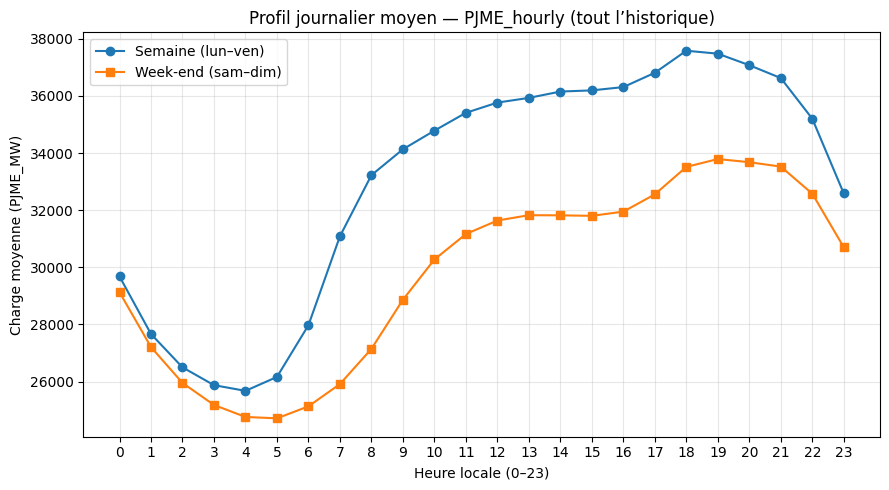

In [9]:
import matplotlib.pyplot as plt

# Colonne de charge (toute colonne *_MW ou la seule colonne numérique hors Datetime)
mw_cols = [c for c in df.columns if c.endswith("_MW")]
value_col = mw_cols[0] if mw_cols else [c for c in df.columns if c != "Datetime"][0]

eda = df[["Datetime", value_col]].copy()
eda["hour"] = eda["Datetime"].dt.hour
eda["is_weekend"] = eda["Datetime"].dt.weekday >= 5

mean_wd = eda.loc[~eda["is_weekend"]].groupby("hour", observed=True)[value_col].mean()
mean_we = eda.loc[eda["is_weekend"]].groupby("hour", observed=True)[value_col].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mean_wd.index, mean_wd.values, marker="o", label="Semaine (lun–ven)")
ax.plot(mean_we.index, mean_we.values, marker="s", label="Week-end (sam–dim)")
ax.set_xlabel("Heure locale (0–23)")
ax.set_ylabel(f"Charge moyenne ({value_col})")
ax.set_title(
    f"Profil journalier moyen — {CSV_PATH.stem} (tout l’historique)"
)
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


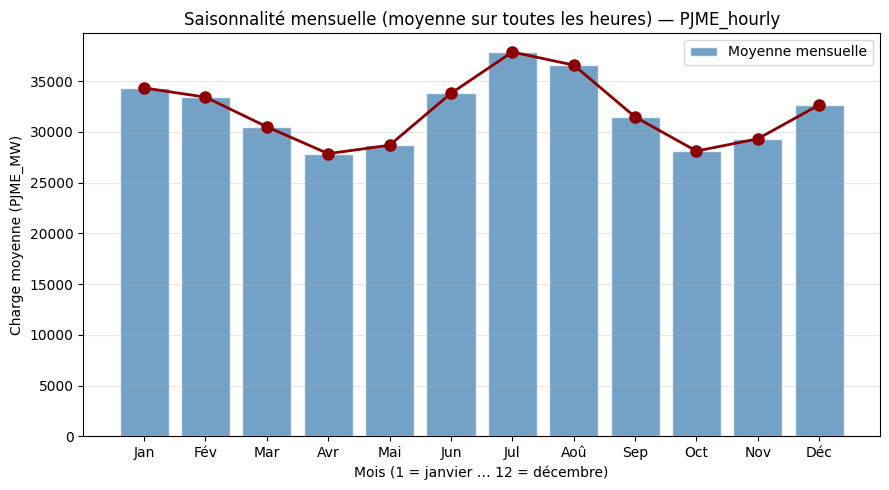

In [10]:
import matplotlib.pyplot as plt


mw_cols = [c for c in df.columns if c.endswith("_MW")]
value_col = mw_cols[0] if mw_cols else [c for c in df.columns if c != "Datetime"][0]

eda_m = df[["Datetime", value_col]].copy()
eda_m["month"] = eda_m["Datetime"].dt.month
mean_by_month = eda_m.groupby("month", observed=True)[value_col].mean().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(mean_by_month.index, mean_by_month.values, color="steelblue", alpha=0.75, edgecolor="white", label="Moyenne mensuelle")
ax.plot(mean_by_month.index, mean_by_month.values, color="darkred", marker="o", linewidth=2, markersize=8, zorder=3)
ax.set_xlabel("Mois (1 = janvier … 12 = décembre)")
ax.set_ylabel(f"Charge moyenne ({value_col})")
ax.set_title(f"Saisonnalité mensuelle (moyenne sur toutes les heures) — {CSV_PATH.stem}")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(
    ["Jan", "Fév", "Mar", "Avr", "Mai", "Jun", "Jul", "Aoû", "Sep", "Oct", "Nov", "Déc"]
)
ax.legend(loc="upper right")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Contrôle qualité temporel : doublons, grille horaire, écarts, valeurs extrêmes (indicatif)

mw_cols = [c for c in df.columns if c.endswith("_MW")]
value_col = mw_cols[0] if mw_cols else [c for c in df.columns if c != "Datetime"][0]

# 1) Doublons sur Datetime
dup_mask = df["Datetime"].duplicated(keep=False)
n_dup_rows = int(dup_mask.sum())
n_dup_extra = int(df["Datetime"].duplicated().sum())
print("=== Horodatages dupliqués ===")
print(f"Lignes concernées par au moins un doublon : {n_dup_rows}")
print(f"Lignes en double (même instant qu'une autre) : {n_dup_extra}")
if n_dup_rows:
    display(df.loc[dup_mask].sort_values("Datetime").head(20))

# 2) Trous dans la grille horaire (une ligne attendue par heure entre min et max)
ts_min, ts_max = df["Datetime"].min(), df["Datetime"].max()
full_hour = pd.date_range(ts_min, ts_max, freq="h")
unique_ts = pd.DatetimeIndex(df["Datetime"].unique()).sort_values()
missing_hours = full_hour.difference(unique_ts)
print("\n=== Trous dans la grille horaire ===")
print(f"Heures manquantes : {len(missing_hours)}")
if len(missing_hours) > 0:
    k = min(15, len(missing_hours))
    print(f"Aperçu ({k} premières) :")
    print(missing_hours[:k].tolist())

# 3) Écarts entre deux instants consécutifs (série triée)
deltas = df["Datetime"].sort_values().diff().dropna()
print("\n=== Écarts entre pas consécutifs (les plus fréquents) ===")
print(deltas.value_counts().head(8))

# 4) Valeurs extrêmes grossières (IQR × 3 — à interpréter avec prudence sur une série longue)
s = df[value_col]
q1, q3 = s.quantile(0.25), s.quantile(0.75)
iqr = q3 - q1
low, high = q1 - 3 * iqr, q3 + 3 * iqr
out_mask = (s < low) | (s > high)
print("\n=== Points hors bornes IQR × 3 (indicatif) ===")
print(f"Nombre : {int(out_mask.sum())} ({100 * out_mask.mean():.2f} %)")
if out_mask.any():
    display(df.loc[out_mask, ["Datetime", value_col]].sort_values("Datetime").head(12))

=== Horodatages dupliqués ===
Lignes concernées par au moins un doublon : 8
Lignes en double (même instant qu'une autre) : 4


,Datetime,PJME_MW
112487,2014-11-02 02:00:00,23755.0
112488,2014-11-02 02:00:00,22935.0
121223,2015-11-01 02:00:00,21567.0
121224,2015-11-01 02:00:00,21171.0
130127,2016-11-06 02:00:00,20795.0
130128,2016-11-06 02:00:00,21692.0
138863,2017-11-05 02:00:00,21236.0
138864,2017-11-05 02:00:00,20666.0



=== Trous dans la grille horaire ===
Heures manquantes : 30
Aperçu (15 premières) :
[Timestamp('2002-04-07 03:00:00'), Timestamp('2002-10-27 02:00:00'), Timestamp('2003-04-06 03:00:00'), Timestamp('2003-10-26 02:00:00'), Timestamp('2004-04-04 03:00:00'), Timestamp('2004-10-31 02:00:00'), Timestamp('2005-04-03 03:00:00'), Timestamp('2005-10-30 02:00:00'), Timestamp('2006-04-02 03:00:00'), Timestamp('2006-10-29 02:00:00'), Timestamp('2007-03-11 03:00:00'), Timestamp('2007-11-04 02:00:00'), Timestamp('2008-03-09 03:00:00'), Timestamp('2008-11-02 02:00:00'), Timestamp('2009-03-08 03:00:00')]

=== Écarts entre pas consécutifs (les plus fréquents) ===
Datetime
0 days 01:00:00    145331
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64

=== Points hors bornes IQR × 3 (indicatif) ===
Nombre : 27 (0.02 %)


,Datetime,PJME_MW
39823,2006-07-18 17:00:00,59943.0
40156,2006-08-01 14:00:00,60028.0
40157,2006-08-01 15:00:00,61004.0
40158,2006-08-01 16:00:00,61366.0
40159,2006-08-01 17:00:00,61643.0
40160,2006-08-01 18:00:00,61155.0
40161,2006-08-01 19:00:00,60047.0
40180,2006-08-02 14:00:00,61008.0
40181,2006-08-02 15:00:00,61641.0
40182,2006-08-02 16:00:00,61909.0


## Nettoyage pour la suite du projet (série régulière 1 h)

Les **doublons** à l’heure répétée (ex. `02:00` en novembre) et les **trous** d’une heure (ex. mars) viennent du **changement d’heure (DST)** en heure locale US, pas d’une erreur de fichier.

**Règles appliquées ci-dessous (à citer dans le rapport) :**

1. **Doublons** : pour un même `Datetime`, on prend la **moyenne** de la charge (les deux mesures correspondent à la même heure civile ambiguë).
2. **Grille complète** : on réindexe de la première à la dernière date avec `freq="h"`.
3. **Trous** : **interpolation linéaire** sur la colonne MW (typiquement le saut d’une heure au printemps), puis `ffill` / `bfill` de secours si une extrémité restait NaN.

Le fichier nettoyé est écrit dans `data/processed/` (ex. `PJME_hourly_clean.csv`) pour que le **prétraitement** et les **fenêtres 168→24** utilisent tous la même série sans doublon ni lacune.

In [12]:
# Nettoyage reproductible (DST) → série strictement horaire, une valeur par pas

DATA_PROCESSED = ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

mw_cols = [c for c in df.columns if c.endswith("_MW")]
value_col = mw_cols[0] if mw_cols else [c for c in df.columns if c != "Datetime"][0]

# 1) Une seule ligne par horodatage : moyenne si doublon (heure ambiguë fin DST)
df_agg = (
    df.groupby("Datetime", as_index=False, observed=True)[value_col]
    .mean()
    .sort_values("Datetime")
    .reset_index(drop=True)
)

# 2) Grille horaire complète entre min et max
full_ix = pd.date_range(df_agg["Datetime"].min(), df_agg["Datetime"].max(), freq="h")
df_clean = df_agg.set_index("Datetime").reindex(full_ix)
df_clean.index.name = "Datetime"
df_clean = df_clean.reset_index()

# 3) Remplir les trous (saut d’heure printemps, etc.)
df_clean[value_col] = df_clean[value_col].interpolate(method="linear", limit_direction="both")
if df_clean[value_col].isna().any():
    df_clean[value_col] = df_clean[value_col].ffill().bfill()

assert df_clean["Datetime"].is_monotonic_increasing
assert not df_clean["Datetime"].duplicated().any()
assert not df_clean[value_col].isna().any()

out_path = DATA_PROCESSED / f"{CSV_PATH.stem}_clean.csv"
df_clean.to_csv(out_path, index=False)

print("Fichier sauvegardé :", out_path.resolve())
print("Lignes : brut =", len(df), "| après agrégation doublons =", len(df_agg), "| grille 1 h =", len(df_clean))
print("Doublons restants :", int(df_clean["Datetime"].duplicated().sum()), "| NaN MW :", int(df_clean[value_col].isna().sum()))

Fichier sauvegardé : C:\Users\fanomezantsoa\Desktop\PJM Hourly Energy Consumption\energy_forecast\data\processed\PJME_hourly_clean.csv
Lignes : brut = 145366 | après agrégation doublons = 145362 | grille 1 h = 145392
Doublons restants : 0 | NaN MW : 0
